In [2]:
import os

print(os.listdir("."))

['explore.ipynb', 'NaukriData_data analytics.csv', 'NaukriData_Data Science.csv', 'Naukri_Data_Scientist_and_Data_Analytics_Jobs_Data.csv']


In [4]:
import pandas as pd

df = pd.read_csv("NaukriData_data analytics.csv")
print(df.shape)
print(df.columns)
df.head()

(20064, 8)
Index(['Job_Titles', 'Company_Names', 'Experience_Required', 'Package_Details',
       'Locations', 'Skills', 'Post_Url', 'Post_Time'],
      dtype='str')


,Job_Titles,Company_Names,Experience_Required,Package_Details,Locations,Skills,Post_Url,Post_Time
0,"Lead Analyst, Data & Analytics",ANZ,4-6 Yrs,Not disclosed,Bangalore/Bengaluru,data cleansingData analysisAutomationData mana...,https://www.naukri.com/job-listings-lead-analy...,3 Days Ago
1,Director Data Analytics (Immediate Joiner pref...,Techneplus Software,10-15 Yrs,Not disclosed,"Noida, Uttar Pradesh, Bangalore/ Bengaluru, Ka...",Data ScienceData VisualizationData ModelingDat...,https://www.naukri.com/job-listings-director-d...,1 Day Ago
2,Data Analytics Lead,Gartner,5-8 Yrs,Not disclosed,Gurgaon/Gurugram,Process designChange managementProject managem...,https://www.naukri.com/job-listings-data-analy...,1 Day Ago
3,Data Analytics Analyst,Leading Indian IT Company,4-7 Yrs,Not disclosed,"Noida, Mumbai, Bangalore/Bengaluru",Data AnalysisRSASPower BIData VisualizationTab...,NaN,2 Days Ago
4,Data Analytics Analyst,Foreign MNC in BPO,7-9 Yrs,Not disclosed,Jaipur,Data AnalyticsData EngineeringScalaHadoopOLAPS...,NaN,1 Day Ago


In [6]:
print(df.columns.tolist())

['Job_Titles', 'Company_Names', 'Experience_Required', 'Package_Details', 'Locations', 'Skills', 'Post_Url', 'Post_Time']


In [7]:
mask = df['Job_Titles'].str.contains("data analyst", case=False, na=False)
data_analyst_jobs = df[mask]
print(len(data_analyst_jobs))
data_analyst_jobs.head()

1085


,Job_Titles,Company_Names,Experience_Required,Package_Details,Locations,Skills,Post_Url,Post_Time
11,Data Analyst - US MNC (analytics),Aspyra Hr Services,7-9 Yrs,Not disclosed,Chennai,SQL queriesData analysisData modelingProgrammi...,https://www.naukri.com/job-listings-data-analy...,4 Days Ago
30,Data Analyst SAS+VBA- US MNC (analytics),Aspyra Hr Services,2-5 Yrs,Not disclosed,Mumbai,ProcurementData analysisSAPAnalyticalpower biF...,https://www.naukri.com/job-listings-data-analy...,30+ Days Ago
33,Data Analyst / data Analytics - US MNC (analyt...,Aspyra Hr Services,6-8 Yrs,Not disclosed,"Gurgaon/Gurugram, Bangalore/ Bengaluru, Karnataka",Visual AnalyticsData Management And AnalysisSQ...,https://www.naukri.com/job-listings-data-analy...,29 Days Ago
46,Data Analyst Risk/Fraud strategy - US MNC (ana...,Aspyra Hr Services,0-3 Yrs,Not disclosed,Hyderabad/Secunderabad,advanced analyticsTalent acquisitionAnalytical...,https://www.naukri.com/job-listings-data-analy...,30+ Days Ago
51,Data Analyst Advanced Analytics,Perceptive Analytics,2-4 Yrs,Not disclosed,New Delhi,Data analysispower biData processingData quali...,https://www.naukri.com/job-listings-data-analy...,30+ Days Ago


In [9]:
mask = df['Job_Titles'].str.contains("data analyst", case=False, na=False)
data_analyst_jobs = df[mask]
print(len(data_analyst_jobs))
print(len(df))

1085
20064


In [10]:
import os
os.makedirs("../Processed", exist_ok=True)
data_analyst_jobs.to_csv("../Processed/data_analyst_filtered.csv", index=False)
print("Saved:", len(data_analyst_jobs), "rows")

Saved: 1085 rows


In [11]:
print(data_analyst_jobs['Skills'].iloc[0])
print(data_analyst_jobs['Skills'].iloc[1])

SQL queriesData analysisData modelingProgrammingData qualityData analyticsFinancial risk managementBusiness intelligence
ProcurementData analysisSAPAnalyticalpower biForensicData analyticsQlikView


Sample 1: SQL queriesData analysisData modelingProgrammingData qualityData analyticsFinancial risk managementBusiness intelligence
Sample 2: ProcurementData analysisSAPAnalyticalpower biForensicData analyticsQlikView
Type: <class 'str'>

Skill Frequency:
 Data_Analysis         477
Analytics             319
SQL                   273
Machine_Learning      150
Excel                 147
Data_Management       134
Python                133
Power_BI               95
Data_Visualization     84
Data_Modeling          79
Tableau                69
Reporting              63
SAS                    57
Data_Warehousing       33
Statistics             25
ETL                    13
VBA                     7
Dashboard               5
Data_Cleaning           4
R_programming           0
dtype: int64


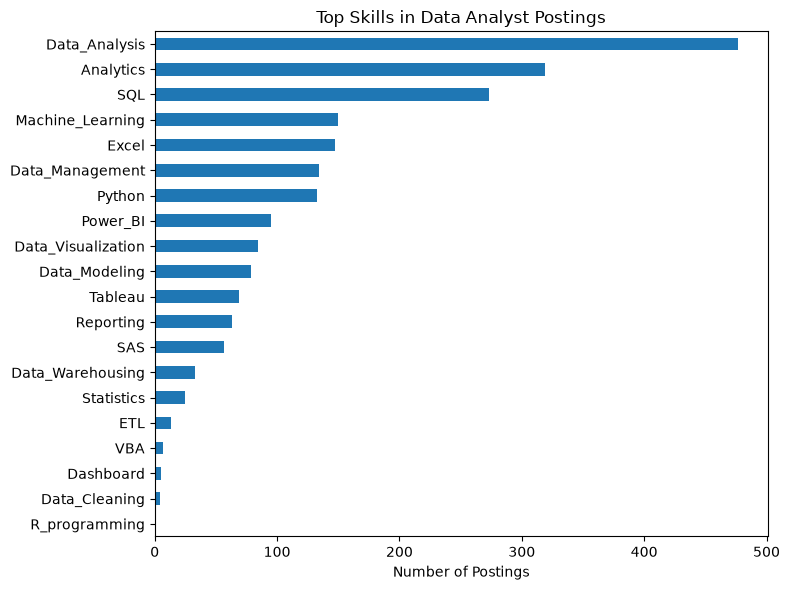

In [12]:
# 1. Skills column ka format dekhne ke liye
print("Sample 1:", data_analyst_jobs['Skills'].iloc[0])
print("Sample 2:", data_analyst_jobs['Skills'].iloc[1])
print("Type:", type(data_analyst_jobs['Skills'].iloc[0]))

# 2. Common skill keywords define karo (basic starting list)
skill_keywords = [
    "SQL", "Python", "Excel", "Power BI", "Tableau", "R programming",
    "Data Analysis", "Data Visualization", "Statistics", "Machine Learning",
    "Data Modeling", "SAS", "VBA", "Data Management", "Analytics",
    "Data Cleaning", "Reporting", "Dashboard", "ETL", "Data Warehousing"
]

# 3. Har posting mein har skill hai ya nahi, ye check karke columns bana do
skills_text = data_analyst_jobs['Skills'].astype(str)

for skill in skill_keywords:
    col_name = skill.replace(" ", "_")
    data_analyst_jobs[col_name] = skills_text.str.contains(skill, case=False, na=False)

# 4. Ab count nikaalo — kaunsi skill kitni baar aayi
skill_columns = [s.replace(" ", "_") for s in skill_keywords]
skill_counts = data_analyst_jobs[skill_columns].sum().sort_values(ascending=False)
print("\nSkill Frequency:\n", skill_counts)

# 5. Chart bana do
import matplotlib.pyplot as plt
skill_counts.plot(kind='barh', figsize=(8,6))
plt.title("Top Skills in Data Analyst Postings")
plt.xlabel("Number of Postings")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [13]:
# STEP A: Skill frequency table save karo (report ke liye)
skill_freq_table = skill_counts.reset_index()
skill_freq_table.columns = ['Skill', 'Number_of_Postings']
skill_freq_table['Percentage'] = (skill_freq_table['Number_of_Postings'] / len(data_analyst_jobs) * 100).round(1)
skill_freq_table.to_csv("../Processed/skill_frequency.csv", index=False)
print(skill_freq_table)

# STEP B: Skill Gap Analyzer function
def skill_gap_analyzer(user_skills, top_n=10):
    top_skills = skill_counts.head(top_n).index.tolist()
    top_skills_clean = [s.replace("_", " ") for s in top_skills]
    user_skills_lower = [s.lower() for s in user_skills]

    have = [s for s in top_skills_clean if s.lower() in user_skills_lower]
    missing = [s for s in top_skills_clean if s.lower() not in user_skills_lower]

    print(f"\n✅ You already have ({len(have)}):")
    for s in have: print("   -", s)
    print(f"\n❌ You are missing ({len(missing)}):")
    for s in missing: print("   -", s)

    coverage = round(len(have) / top_n * 100, 1)
    print(f"\n📊 Coverage of top {top_n} market skills: {coverage}%")
    return have, missing

# Test karo apni skills daal ke:
my_skills = ["Python", "SQL", "Excel"]
have, missing = skill_gap_analyzer(my_skills, top_n=10)

                 Skill  Number_of_Postings  Percentage
0        Data_Analysis                 477        44.0
1            Analytics                 319        29.4
2                  SQL                 273        25.2
3     Machine_Learning                 150        13.8
4                Excel                 147        13.5
5      Data_Management                 134        12.4
6               Python                 133        12.3
7             Power_BI                  95         8.8
8   Data_Visualization                  84         7.7
9        Data_Modeling                  79         7.3
10             Tableau                  69         6.4
11           Reporting                  63         5.8
12                 SAS                  57         5.3
13    Data_Warehousing                  33         3.0
14          Statistics                  25         2.3
15                 ETL                  13         1.2
16                 VBA                   7         0.6
17        